*We want to extend the "Quantum Potentials.ipynb" code for solving the time-dependent Schrodinger equation for any potential in one dimension*

---

The time-dependent Schrodinger equation in one dimension is: 

$$ i \hbar \frac{\partial}{\partial t} \psi(x,t) = -\frac{\hbar^2}{2m}\frac{\partial^2}{\partial x^2}\psi(x,t) + V(x) \psi(x,t) \quad \quad \psi(0, t) = \psi(L,t)=0 \quad \quad \psi(x, 0) = \psi_0(x) $$

Multiplying both sides by $\frac{m L ^ 2}{\hbar ^ 2}$ (where $L$ is the characteristic length of the problem) we obtain:

$$ i \frac{m L ^ 2}{\hbar} \frac{\partial}{\partial t} \psi(x', t') = -\frac{1}{2} L^2\frac{\partial^2}{\partial x^2}\psi(x', t') + \frac{mL^2}{\hbar ^ 2} V(x) \psi(x', t') $$

Consider:

* $x'= x / L$
* $t' = t / \frac{m L ^ 2}{\hbar}$
* $V' = V / \frac{\hbar ^ 2}{m L ^ 2}$
* $\psi' = \psi / \frac{1}{\sqrt{L}}$

All of the four quantities above are dimensionless, therefore the equation becomes:

$$
i \frac{\partial \psi'(x', t')}{\partial t'} = -\frac{1}{2} \frac{\partial^2 \psi'(x', t')}{\partial x'^2} + V'(x') \psi'(x', t') \quad \quad \psi'(0, t') = \psi'(1, t') = 0 \quad \quad \psi'(x', 0) = \psi'_0(x')
$$

Let's solve it

In [1]:
# Importing libraries
import numpy as np
from scipy.linalg import eigh_tridiagonal
from scipy.integrate import trapezoid

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

plt.style.use("classic")

In [2]:
# Grid
N = 10_000
x_prime = np.linspace(0, 1, N)
dx_prime = x_prime[1] - x_prime[0]

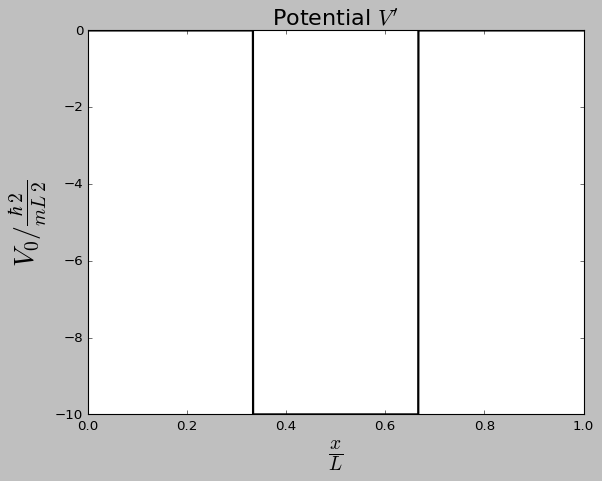

In [3]:
# The potential V_prime
def V_prime(x_prime):
    return np.where(np.abs(x_prime - 0.5) <= 1 / 6, - 10, 0)

plt.plot(x_prime, V_prime(x_prime), color = 'black', linewidth = 2)
plt.title(r"Potential $V'$", fontsize = 20)
plt.xlabel(r"$\frac{x}{L}$", fontsize = 25)
plt.ylabel(r"$V_0 / \frac{\hbar ^ 2}{m L ^ 2}$", fontsize = 25)
plt.show()

In [4]:
# Finding the eigenvalues and eigenstates of the hamiltonian
d = 1 / (dx_prime ** 2) + V_prime(x_prime)[1:-1]
e = - 1 / (2 * dx_prime ** 2) * np.ones(len(d) - 1)
energy_prime, eigenstates_prime = eigh_tridiagonal(d, e, select = 'i', select_range = (0, 100)) # Find only first 100 eigenvalues and eigenstates

eigenstates_prime = eigenstates_prime.T
norms = np.sqrt(trapezoid(eigenstates_prime ** 2, x_prime[1:-1], axis = 1))
eigenstates_prime = eigenstates_prime / norms[:, np.newaxis]

In [5]:
# Ground state energy level [E / (hbar ^ 2 / m L ^ 2)]
round(energy_prime[0], 3) 

np.float64(-1.583)

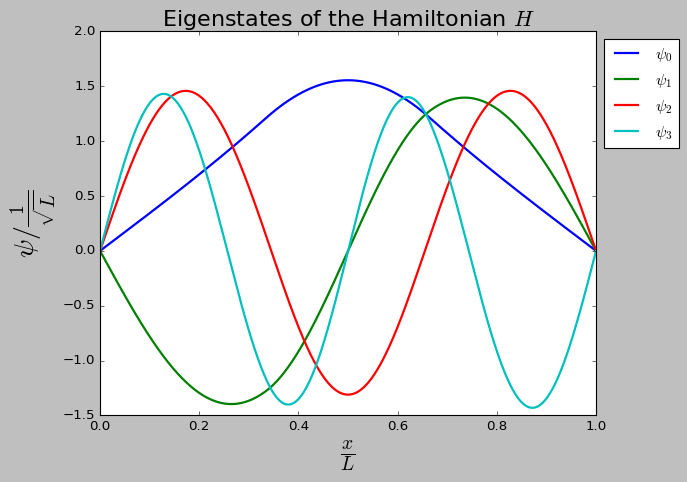

In [6]:
# Plotting first 4 eigenstates of the hamiltonian
plt.plot(x_prime[1:-1], eigenstates_prime[0], linewidth = 2, label = r'$\psi_0$')
plt.plot(x_prime[1:-1], eigenstates_prime[1], linewidth = 2, label = r'$\psi_1$')
plt.plot(x_prime[1:-1], eigenstates_prime[2], linewidth = 2, label = r'$\psi_2$')
plt.plot(x_prime[1:-1], eigenstates_prime[3], linewidth = 2, label = r'$\psi_3$')
plt.title(r"Eigenstates of the Hamiltonian $H$", fontsize = 20)
plt.xlabel(r"$\frac{x}{L}$", fontsize = 25)
plt.ylabel(r"$\psi / \frac{1}{\sqrt{L}}$", fontsize = 25)
plt.legend(bbox_to_anchor = (1, 1), loc = 'upper left')
plt.show()

$\psi'(x',t')$ is given by:

$$
    \psi'(x',t') = \sum_{j = 0} ^ \infty c_j \psi_j'(x') e ^ {- i E_j' t'} \quad \quad c_j = \int _ {0} ^ {1} \psi_0'(x') \psi_j ^ {'*} (x') dx'
$$

Note that:

$$
    e ^ {- \frac{i}{\hbar} E t} = e ^ {- i E' t'}
$$

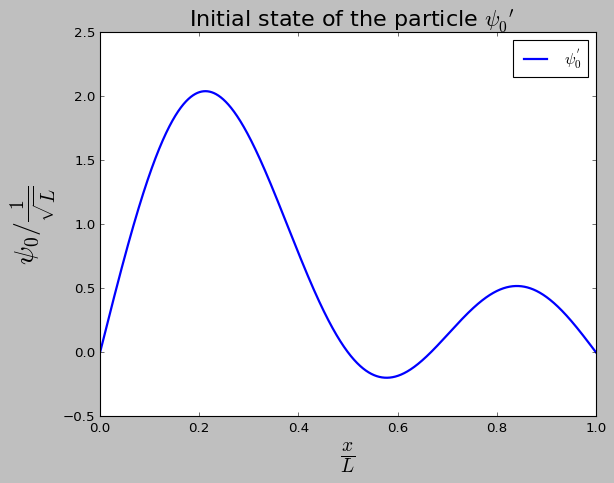

In [7]:
# psi0_prime
psi0_prime = np.sqrt(2 / 3) * (np.sin(np.pi * x_prime) + np.sin(2 * np.pi * x_prime) + np.sin(3 * np.pi * x_prime))

plt.plot(x_prime, psi0_prime, linewidth = 2, label = r"$\psi_0^{'}$")
plt.title(r" Initial state of the particle $\psi_0 ^ {'}$", fontsize = 20)
plt.xlabel(r"$\frac{x}{L}$", fontsize = 25)
plt.ylabel(r"$\psi_0 / \frac{1}{\sqrt{L}}$", fontsize = 25)
plt.legend(loc = 'best')
plt.show()

In [8]:
# Computing the evolution of psi0_prime in time
psi_js_prime = np.pad(eigenstates_prime, [(0, 0), (1, 1)], mode = 'constant')
dots = trapezoid(psi_js_prime * psi0_prime[np.newaxis, :], x_prime, axis = 1)

psi_time_prime = lambda t_prime: psi_js_prime.T @ (dots * np.exp(-1j * energy_prime * t_prime))
prob = lambda t_prime: np.abs(psi_time_prime(t_prime)) ** 2

In [9]:
# Energy values (100 values) [E / (hbar ^ 2 / m L ^ 2)]
energy_prime

array([-1.58313387e+00,  1.76152272e+01,  4.14291753e+01,  7.49525387e+01,
        1.20576292e+02,  1.74411691e+02,  2.38081775e+02,  3.12835586e+02,
        3.96426755e+02,  4.89872126e+02,  5.94026661e+02,  7.07300695e+02,
        8.30435636e+02,  9.64082719e+02,  1.10701008e+03,  1.25980141e+03,
        1.42298298e+03,  1.59554872e+03,  1.77798008e+03,  1.97071870e+03,
        2.17291419e+03,  2.38497625e+03,  2.60728541e+03,  2.83910512e+03,
        3.08079201e+03,  3.33268035e+03,  3.59412053e+03,  3.86542825e+03,
        4.14690160e+03,  4.43795952e+03,  4.73888522e+03,  5.04994765e+03,
        5.37062122e+03,  5.70116272e+03,  6.04181717e+03,  6.39210474e+03,
        6.75226032e+03,  7.12250891e+03,  7.50240912e+03,  7.89217737e+03,
        8.29202167e+03,  8.70153334e+03,  9.12091306e+03,  9.55035420e+03,
        9.98947633e+03,  1.04384665e+04,  1.08975053e+04,  1.13662369e+04,
        1.18448365e+04,  1.23334736e+04,  1.28318139e+04,  1.33400220e+04,
        1.38582577e+04,  

In [10]:
# Basis (100 eigenstates) [psi / (1 / sqrt(L)]
psi_js_prime

array([[ 0.        ,  0.00034131,  0.00068263, ...,  0.00068246,
         0.00034123,  0.        ],
       [ 0.        , -0.00082898, -0.00165796, ...,  0.0016581 ,
         0.00082905,  0.        ],
       [ 0.        ,  0.00132754,  0.00265507, ...,  0.00265513,
         0.00132757,  0.        ],
       ...,
       [ 0.        ,  0.04398185,  0.08792115, ...,  0.08792116,
         0.04398185,  0.        ],
       [ 0.        ,  0.04442491,  0.08880597, ..., -0.08880572,
        -0.04442478,  0.        ],
       [ 0.        , -0.0448689 , -0.08969262, ..., -0.08969287,
        -0.04486902,  0.        ]], shape=(101, 10000))

In [11]:
# Dot products <psi_js_prime, psi0_prime>
dots

array([ 5.18598392e-01, -5.76560096e-01,  6.30605215e-01,  2.85403044e-02,
       -8.94425917e-03,  7.30317977e-03, -4.16585898e-03, -9.46078318e-04,
        1.76843653e-03,  8.77671714e-04,  1.95188108e-04,  7.83409802e-04,
       -4.37137983e-04,  1.97331631e-04,  3.82469404e-04,  1.89129786e-04,
       -8.46285694e-05,  2.25948600e-04, -1.23902376e-04,  7.09041867e-05,
       -1.39354129e-04,  6.91462237e-05,  3.93251491e-05, -9.44359248e-05,
        5.11412811e-05, -3.30975340e-05, -6.55574246e-05, -3.26429524e-05,
       -2.10188949e-05, -4.81434030e-05,  2.58413479e-05,  1.80305516e-05,
       -3.59031943e-05, -1.79331139e-05, -1.24565825e-05, -2.77957807e-05,
       -1.48246733e-05, -1.08786002e-05,  2.17499074e-05,  1.08941279e-05,
        7.96117932e-06,  1.74794443e-05,  9.27928092e-06, -7.05761147e-06,
        1.41578799e-05, -7.10949482e-06,  5.38607792e-06,  1.16991835e-05,
        6.18956326e-06, -4.83399397e-06, -9.72556051e-06, -4.89532377e-06,
        3.80873574e-06,  

In [12]:
# Check: are the eigenstates normalized?
trapezoid(psi_js_prime ** 2, x_prime)

array([1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.00000001, 1.00000001, 1.00000001, 1.00000001, 1.00000001,
       1.00000001, 1.00000001, 1.00000001, 1.00000001, 1.00000001,
       1.00000001, 1.00000001, 1.00000002, 1.00000002, 1.00000002,
       1.00000002, 1.00000002, 1.00000002, 1.00000002, 1.00000002,
       1.00000003, 1.00000003, 1.00000003, 1.00000003, 1.00000003,
       1.00000003, 1.00000003, 1.00000004, 1.00000004, 1.00000004,
       1.00000004, 1.00000004, 1.00000005, 1.00000005, 1.00000005,
       1.00000005, 1.00000005, 1.00000006, 1.00000006, 1.00000006,
       1.00000006, 1.00000006, 1.00000007, 1.00000007, 1.00000007,
       1.00000007, 1.00000008, 1.00000008, 1.00000008, 1.00000008,
       1.00000009, 1.00000009, 1.00000009, 1.00000009, 1.0000001 ,
       1.0000001 , 1.0000001 , 1.00000011, 1.00000011, 1.00000

In [13]:
# Check: are the eigenstates orthogonal to each other?
np.dot(psi_js_prime, psi_js_prime[0]) * dx_prime

array([ 1.00000000e+00, -1.93286953e-16, -2.16026594e-16, -3.41094623e-17,
        6.82189245e-17, -1.13698208e-17, -1.27910483e-16, -7.56803694e-17,
        9.66434764e-17,  0.00000000e+00, -1.70547311e-17, -2.84245519e-17,
        2.27396415e-17,  8.52736557e-18,  2.55820967e-17,  5.11641934e-17,
        1.70547311e-17,  4.26368278e-17, -4.26368278e-18, -2.98457795e-17,
       -1.84759587e-17,  1.13698208e-17, -2.27396415e-17,  4.26368278e-18,
       -6.39552417e-18, -9.94859316e-18,  2.84245519e-18,  4.26368278e-18,
       -1.13698208e-17, -1.70547311e-17, -1.91865725e-17, -5.68491038e-18,
       -1.70547311e-17,  1.42122759e-17, -2.84245519e-18, -1.53670234e-17,
        1.42122759e-18,  2.84245519e-18, -8.52736557e-18, -1.84759587e-17,
        1.88312656e-17, -4.26368278e-18,  4.26368278e-18, -2.55820967e-17,
        1.06592070e-17, -7.10613797e-19, -4.88546986e-18, -3.55306899e-18,
        1.06592070e-17,  1.63441173e-17, -2.13184139e-18,  2.66480174e-18,
       -6.75083107e-18, -

In [14]:
# Check: is psi'(x', t') normalized for each time?
for j in np.linspace(0, 5, 20):
    print(trapezoid(prob(j), x_prime))

1.000000000176965
1.000000000176965
1.000000000176965
1.000000000176965
1.000000000176965
1.0000000001769649
1.000000000176965
1.000000000176965
1.000000000176965
1.000000000176965
1.000000000176965
1.000000000176965
1.000000000176965
1.000000000176965
1.000000000176965
1.0000000001769649
1.000000000176965
1.0000000001769649
1.000000000176965
1.000000000176965


Creating a probability animation...


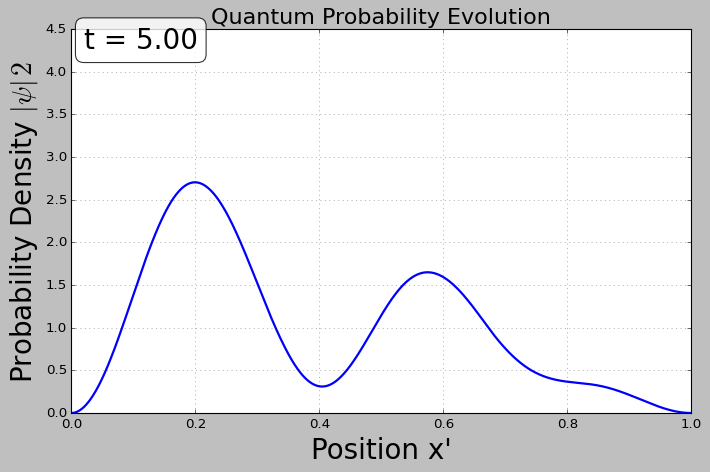

Done


In [15]:
# Animation
def animation():

    print("Creating a probability animation...")

    fig, ax = plt.subplots(figsize = (10, 6))
    t_values = np.linspace(0, 5, 500)
    
    line, = ax.plot(x_prime, prob(0), 'b-', linewidth = 2)
    ax.set_xlabel("Position x'", fontsize = 25)
    ax.set_ylabel(r"Probability Density $| \psi | ^ 2$", fontsize = 25)
    ax.set_title("Quantum Probability Evolution", fontsize = 20)
    ax.grid(True, alpha = 0.5)
    
    # Add time counter
    time_text = ax.text(0.02, 0.95, 't = 0.00', transform = ax.transAxes, 
                       fontsize = 25, bbox = dict(boxstyle = 'round', facecolor = 'white', alpha = 0.8))
    
    def update(frame):
        t = t_values[frame]
        line.set_ydata(prob(t))
        time_text.set_text(f't = {t:.2f}')
        return line, time_text
    
    anim = FuncAnimation(
        fig, 
        update, 
        frames = len(t_values),
        interval = 20,
        blit = True,
        repeat = True
    )
    
    # Save as GIF
    anim.save('Quantum_Evolution.gif', writer = 'pillow', fps = 30, dpi = 100)
    plt.show()
    print("Done")

    return None

animation()